# jcpenney-customer-insight-analysis

We will need these five files.

- jcpenney_reviewers.json
- jcpenney_products.json
- products.csv
- reviews.csv
- users.csv

The data in these files describes products that have been sold by the American retail giant, JC Penney, and reviews by customers who bought them. Note that the product data is real, but the customer data is synthetic.


# **Data Exploration**


* In this section, we will explore the structure of the data, how different datasets are related, and what each file contains.  
* We will start with general data exploration, including loading and inspecting the data.  
* We will apply necessary data transformations to ensure clarity and consistency.  
* Descriptive statistics will be used to summarize key insights from the data.  
* Finally, we will provide an overall summary to better understand the dataset.







**Data Loading**
* We will load data from both JSON and CSV files.  
* For JSON files, we will open and map them to a list of JSON objects, allowing us to read them as a pandas DataFrame.  
* We will create a new DataFrame and perform necessary actions on the JSON data.  
* For CSV files, we will simply load them using the `read_csv()` function.





In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Importing the basic libraries, for whole assignment at once
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import cv2
from datetime import datetime
from PIL import Image
from io import BytesIO
import json
import requests
import re
# We will open the JSON file in read mode.
# Since the data is not already in a list of objects, we will first map it accordingly.
# Once mapped, we will append it to a list of objects for further processing.

reviewers_json_data = []
with open('/content/drive/MyDrive/jcpenney-customer-insight-analysis/jcpenney_reviewers.json', 'r') as file:
    for line in file:
        reviewers_json_data.append(json.loads(line))

# Instead of json.load(), read the file line by line and append each JSON object
products_json_data = []
with open('/content/drive/MyDrive/jcpenney-customer-insight-analysis/jcpenney_products.json', 'r') as file:
    for line in file:
        try:  # Handle potential JSONDecodeError for invalid lines
            products_json_data.append(json.loads(line))
        except json.JSONDecodeError as e:
            print(f"Skipping invalid line: {e}")
# Changed to json.load() to handle a list of JSON objects

# We will load the list of JSON objects as a DataFrame.
# This will allow us to leverage pandas functionalities for data analysis and manipulation.
jc_reviewers = pd.DataFrame(reviewers_json_data)
jc_products = pd.DataFrame(products_json_data)
# We will load three CSV files.
# Each CSV file will be read using the `read_csv()` function.
# Once loaded, we can apply various pandas operations for further analysis.
products = pd.read_csv('/content/drive/MyDrive/jcpenney-customer-insight-analysis/products.csv')
reviews = pd.read_csv('/content/drive/MyDrive/jcpenney-customer-insight-analysis/reviews.csv')
users = pd.read_csv('/content/drive/MyDrive/jcpenney-customer-insight-analysis/users.csv')

Skipping invalid line: Extra data: line 1 column 631 (char 630)
Skipping invalid line: Extra data: line 1 column 767 (char 766)
Skipping invalid line: Expecting ',' delimiter: line 2 column 1 (char 3979)
Skipping invalid line: Expecting ',' delimiter: line 2 column 1 (char 5557)
Skipping invalid line: Extra data: line 1 column 1629 (char 1628)
Skipping invalid line: Expecting value: line 1 column 12 (char 11)
Skipping invalid line: Expecting ',' delimiter: line 2 column 1 (char 5785)
Skipping invalid line: Expecting ',' delimiter: line 1 column 759 (char 758)
Skipping invalid line: Expecting value: line 1 column 12 (char 11)
Skipping invalid line: Expecting ',' delimiter: line 1 column 1458 (char 1457)
Skipping invalid line: Extra data: line 1 column 1135 (char 1134)
Skipping invalid line: Expecting ',' delimiter: line 2 column 1 (char 5678)
Skipping invalid line: Expecting ',' delimiter: line 2 column 1 (char 6058)
Skipping invalid line: Extra data: line 1 column 3035 (char 3034)
Skip

* We will display the first five rows of the DataFrames using the `head()` method.   
* We can specify a parameter in `head(n)` to retrieve the first `n` rows, e.g., `head(10)` for the first ten rows.   
* To view the last five rows, we will use the `tail()` method, which works similarly to `head()` but retrieves rows from the end of the DataFrame.

In [3]:
print("JC Reviewers JSON")
display(jc_reviewers.head())
print("\nJC Products JSON")
display(jc_products.head())
print("\nProducts CSV")
display(products.head())
print("\nReviews CSV")
display(reviews.head())
print("\nUsers CSV")
display(users.head())

JC Reviewers JSON


,Username,DOB,State,Reviewed
0,bkpn1412,31.07.1983,Oregon,[cea76118f6a9110a893de2b7654319c0]
1,gqjs4414,27.07.1998,Massachusetts,[fa04fe6c0dd5189f54fe600838da43d3]
2,eehe1434,08.08.1950,Idaho,[]
3,hkxj1334,03.08.1969,Florida,"[f129b1803f447c2b1ce43508fb822810, 3b0c9bc0be6..."
4,jjbd1412,26.07.2001,Georgia,[]



JC Products JSON


,uniq_id,sku,name_title,description,list_price,sale_price,category,category_tree,average_product_rating,product_url,product_image_urls,brand,total_number_reviews,Reviews,Bought With
0,b6c0b6bea69c722939585baeac73c13d,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,alfred dunner,jcpenney|women|alfred dunner,2.625,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'fsdv4141', 'Review': 'You never hav...","[898e42fe937a33e8ce5e900ca7a4d924, 8c02c262567..."
1,93e5272c51d8cce02597e3ce67b7ad0a,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,alfred dunner,jcpenney|women|alfred dunner,3.000,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'tpcu2211', 'Review': 'You never hav...","[bc9ab3406dcaa84a123b9da862e6367d, 18eb69e8fc2..."
2,013e320f2f2ec0cf5b3ff5418d688528,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,view all,jcpenney|women|view all,2.625,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'pcfg3234', 'Review': 'You never hav...","[3ce70f519a9cfdd85cdbdecd358e5347, b0295c96d2b..."
3,505e6633d81f2cb7400c0cfa0394c427,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,view all,jcpenney|women|view all,3.500,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'ngrq4411', 'Review': 'You never hav...","[efcd811edccbeb5e67eaa8ef0d991f7c, 7b2cc00171e..."
4,d969a8542122e1331e304b09f81a83f6,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,view all,jcpenney|women|view all,3.125,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'nbmi2334', 'Review': 'You never hav...","[0ca5ad2a218f59eb83eec1e248a0782d, 9869fc8da14..."



Products CSV


,Uniq_id,SKU,Name,Description,Price,Av_Score
0,b6c0b6bea69c722939585baeac73c13d,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625
1,93e5272c51d8cce02597e3ce67b7ad0a,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.000
2,013e320f2f2ec0cf5b3ff5418d688528,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625
3,505e6633d81f2cb7400c0cfa0394c427,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.500
4,d969a8542122e1331e304b09f81a83f6,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.125



Reviews CSV


,Uniq_id,Username,Score,Review
0,b6c0b6bea69c722939585baeac73c13d,fsdv4141,2,You never have to worry about the fit...Alfred...
1,b6c0b6bea69c722939585baeac73c13d,krpz1113,1,Good quality fabric. Perfect fit. Washed very ...
2,b6c0b6bea69c722939585baeac73c13d,mbmg3241,2,I do not normally wear pants or capris that ha...
3,b6c0b6bea69c722939585baeac73c13d,zeqg1222,0,I love these capris! They fit true to size and...
4,b6c0b6bea69c722939585baeac73c13d,nvfn3212,3,This product is very comfortable and the fabri...



Users CSV


,Username,DOB,State
0,bkpn1412,31.07.1983,Oregon
1,gqjs4414,27.07.1998,Massachusetts
2,eehe1434,08.08.1950,Idaho
3,hkxj1334,03.08.1969,Florida
4,jjbd1412,26.07.2001,Georgia


## **Structure of Datasets**  

Below is the structure and relationships of the datasets:  

### **Datasets Overview**  

* **`jcpenny_reviewers.json`** (Username, DOB, State, Reviewed)  
  * Contains reviews by JCPenney users.  
  * `Username` is unique.  

*  **`jcpenny_products.json`** (uniq_id, sku, name_title, description, list_price, sale_price, category, category_tree, average_product_rating, product_url, product_image_urls, brand, total_number_reviews, Reviews, Bought With)  
  * Contains product details, including images, prices, and associated products.  
  * `uniq_id` is unique.  

* **`products.csv`** (Uniq_id, SKU, Name, Description, Price, Av_Score)  
  * Contains product information.  
  * `uniq_id` is unique.  

* **`reviews.csv`** (Uniq_id, Username, Score, Review)  
  * Contains product reviews.  
  * (`Uniq_id`, `Username`) forms a multi-indexed key.  

* **`users.csv`** (Username, DOB, State)  
  * Contains user details.  

### **Relationships in the Data**  

* **`jcpenny_reviewers.json` ↔ `users.csv`**  
  * Both datasets contain user details. They are linked via the `Username` field.  

* **`jcpenny_products.json` ↔ `products.csv`**  
  * The `uniq_id` field is common between these datasets, linking product details.  

* **`jcpenny_products.json` ↔ `reviews.csv`**  
  * The `uniq_id` field connects products to their reviews.  

* **`reviews.csv` ↔ `users.csv`**  
  * The `Username` field connects users to their reviews.  

## **Data Types**  
Now, we will explore the data types of each DataFrame.

In [4]:
print("JC Reviewers\n")
print(jc_reviewers.dtypes)
print("\nJC Products\n")
print(jc_products.dtypes)
print("\nProducts\n")
print(products.dtypes)
print("\nReviews\n")
print(reviews.dtypes)
print("\nUsers\n")
print(users.dtypes)

JC Reviewers

Username    object
DOB         object
State       object
Reviewed    object
dtype: object

JC Products

uniq_id                    object
sku                        object
name_title                 object
description                object
list_price                 object
sale_price                 object
category                   object
category_tree              object
average_product_rating    float64
product_url                object
product_image_urls         object
brand                      object
total_number_reviews        int64
Reviews                    object
Bought With                object
dtype: object

Products

Uniq_id         object
SKU             object
Name            object
Description     object
Price          float64
Av_Score       float64
dtype: object

Reviews

Uniq_id     object
Username    object
Score        int64
Review      object
dtype: object

Users

Username    object
DOB         object
State       object
dtype: object


## **Descriptive Statistics**  

We will use the `describe()` method to generate descriptive statistics for numerical and object (categorical) data in each DataFrame.  

### **For Numerical Data:**  
* **`count`** – Number of non-empty values.  
* **`mean`** – Average value.  
* **`std`** – Standard deviation.  
* **`min`** – Minimum value.  
* **`25%`** – First quartile (25th percentile).  
* **`50%`** – Median (50th percentile).  
* **`75%`** – Third quartile (75th percentile).  
* **`max`** – Maximum value.  

### **For Object (Categorical) Data:**  
* **`top`** – Most common value.  
* **`freq`** – Frequency of the most common value.  
* **`unique`** – Number of unique values.  

By analyzing these statistics, we can gain insights into the distribution, spread, and common patterns in the dataset.

In [5]:
print("JC Reviewers Statistics - e.g it shows that massachusetts is most ocurring state in")
display(jc_reviewers.describe())
print("\nJC Products Statistics")
display(jc_products.describe())
print("\nProducts Statistics")
display(products.describe())
print("\nReviews Statistics")
display(reviews.describe())
print("\nUsers Statistics")
display(users.describe())

display(jc_products.describe())
print("\nProducts Statistics")
display(products.describe())
print("\nReviews Statistics")
display(reviews.describe())
print("\nUsers Statistics")
display(users.describe())

JC Reviewers Statistics - e.g it shows that massachusetts is most ocurring state in


,Username,DOB,State,Reviewed
count,5000,5000,5000,5000
unique,4999,52,57,4030
top,dqft3311,07.08.1953,Massachusetts,[]
freq,2,112,107,971



JC Products Statistics


,average_product_rating,total_number_reviews
count,19174.000000,19178.000000
mean,2.987104,4.874909
std,0.913724,3.321086
min,1.000000,1.000000
25%,2.500000,2.000000
50%,3.000000,4.000000
75%,3.500000,8.000000
max,5.000000,23.000000



Products Statistics


...

,Price,Av_Score
count,5816.000000,7982.000000
mean,144.776618,2.988683
std,499.223719,0.911673
min,-65.270000,1.000000
25%,40.700000,2.500000
50%,58.010000,3.000000
75%,87.020000,3.500000
max,17122.170000,5.000000



Reviews Statistics


,Score
count,39063.000000
mean,1.487648
std,1.400332
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,5.000000



Users Statistics


,Username,DOB,State
count,5000,5000,5000
unique,4999,52,57
top,dqft3311,07.08.1953,Massachusetts
freq,2,112,107


* We can use the `unique()` function to retrieve distinct values from any column.  
* For example, to get a list of unique states from the `users.csv` dataset, we can apply `unique()` to the **State** column.  
* This helps in analyzing the diversity of data, such as identifying users from different states.

In [6]:
#To determine how many unique states our users belong to, we will check the distinct values in the **State** column.
# This will help us understand the geographic distribution of users across different regions.
display(users['State'].unique())
# We will count the total number of unique states from which users are present.
# For example, if users come from **57 different states**, this gives us insight into the geographical spread of our user base.
print(len(users['State'].unique()))

array(['Oregon', 'Massachusetts', 'Idaho', 'Florida', 'Georgia',
       'Montana', 'Pennsylvania', 'Connecticut', 'Arkansas', 'Nebraska',
       'California', 'New Hampshire', 'District of Columbia',
       'Washington', 'Minnesota', 'New Mexico', 'Virginia', 'Kansas',
       'Illinois', 'North Dakota', 'Colorado', 'New York',
       'Minor Outlying Islands', 'Northern Mariana Islands',
       'West Virginia', 'Texas', 'South Dakota', 'Maryland', 'Maine',
       'Ohio', 'Rhode Island', 'Michigan', 'Alaska', 'Iowa', 'Oklahoma',
       'Mississippi', 'South Carolina', 'Missouri', 'New Jersey',
       'Tennessee', 'North Carolina', 'Guam', 'Wyoming', 'Delaware',
       'Vermont', 'Indiana', 'Louisiana', 'Wisconsin', 'Hawaii',
       'Puerto Rico', 'Alabama', 'Kentucky', 'Arizona', 'Nevada', 'Utah',
       'American Samoa', 'U.S. Virgin Islands'], dtype=object)

57


## **Display Index, Columns, and Data**  

* Pandas provides the `info()` function for a basic inspection of the DataFrame, including details about indexes, columns, and data types.  
* Additionally, we can use the `shape` attribute to get the dimensions of the DataFrame, which tells us the number of rows and columns it contains.

In [7]:
print("JC Reviewers Info")
display(jc_reviewers.info())
print("\nJC Products Info")
display(jc_products.info())
print("\nProducts Info")
display(products.info())
print("\nReviews Info")
display(reviews.info())
print("\nUsers Info")
display(users.info())

JC Reviewers Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Username  5000 non-null   object
 1   DOB       5000 non-null   object
 2   State     5000 non-null   object
 3   Reviewed  5000 non-null   object
dtypes: object(4)
memory usage: 156.4+ KB


None


JC Products Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19178 entries, 0 to 19177
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   uniq_id                 19178 non-null  object 
 1   sku                     19178 non-null  object 
 2   name_title              19178 non-null  object 
 3   description             19177 non-null  object 
 4   list_price              19174 non-null  object 
 5   sale_price              19174 non-null  object 
 6   category                19174 non-null  object 
 7   category_tree           19174 non-null  object 
 8   average_product_rating  19174 non-null  float64
 9   product_url             19174 non-null  object 
 10  product_image_urls      19176 non-null  object 
 11  brand                   19178 non-null  object 
 12  total_number_reviews    19178 non-null  int64  
 13  Reviews                 19178 non-null  object 
 14  Bought With         

None


Products Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7982 entries, 0 to 7981
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Uniq_id      7982 non-null   object 
 1   SKU          7915 non-null   object 
 2   Name         7982 non-null   object 
 3   Description  7439 non-null   object 
 4   Price        5816 non-null   float64
 5   Av_Score     7982 non-null   float64
dtypes: float64(2), object(4)
memory usage: 374.3+ KB


None


Reviews Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39063 entries, 0 to 39062
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Uniq_id   39063 non-null  object
 1   Username  39063 non-null  object
 2   Score     39063 non-null  int64 
 3   Review    39063 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.2+ MB


None


Users Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Username  5000 non-null   object
 1   DOB       5000 non-null   object
 2   State     5000 non-null   object
dtypes: object(3)
memory usage: 117.3+ KB


None

## **Data Formatting and Conversion**  

* In this section, we will format and convert data where necessary.  
* For example, if a date is in the format **dd.mm.yyyy**, we can update it to **dd-mm-yyyy** using Pandas' `to_datetime()` function along with `strftime()` to ensure consistency in our dataset.

In [8]:
jc_reviewers['DOB'] = pd.to_datetime(jc_reviewers['DOB'],format='%d.%m.%Y').dt.strftime('%d.%m.%Y')
display(jc_reviewers.head())
# Similarly, for the users DataFrame, we will apply the same formatting and conversion techniques as needed.
# This ensures consistency and standardization across all datasets.
users['DOB'] = pd.to_datetime(users['DOB'],format='%d.%m.%Y').dt.strftime('%d.%m.%Y')
display(users.head())


,Username,DOB,State,Reviewed
0,bkpn1412,31.07.1983,Oregon,[cea76118f6a9110a893de2b7654319c0]
1,gqjs4414,27.07.1998,Massachusetts,[fa04fe6c0dd5189f54fe600838da43d3]
2,eehe1434,08.08.1950,Idaho,[]
3,hkxj1334,03.08.1969,Florida,"[f129b1803f447c2b1ce43508fb822810, 3b0c9bc0be6..."
4,jjbd1412,26.07.2001,Georgia,[]


,Username,DOB,State
0,bkpn1412,31.07.1983,Oregon
1,gqjs4414,27.07.1998,Massachusetts
2,eehe1434,08.08.1950,Idaho
3,hkxj1334,03.08.1969,Florida
4,jjbd1412,26.07.2001,Georgia


In [9]:
# To maintain consistency, we will convert **Usernames** to lowercase wherever uppercase letters are present.
# This helps in avoiding case-sensitive mismatches when performing operations like merging and grouping on the column.
users['Username'] = users['Username'].str.lower()
reviews['Username'] = reviews['Username'].str.lower()
jc_reviewers['Username'] = jc_reviewers['Username'].str.lower()
display(users.head())
display(reviews.head())
display(jc_reviewers.head())

,Username,DOB,State
0,bkpn1412,31.07.1983,Oregon
1,gqjs4414,27.07.1998,Massachusetts
2,eehe1434,08.08.1950,Idaho
3,hkxj1334,03.08.1969,Florida
4,jjbd1412,26.07.2001,Georgia


,Uniq_id,Username,Score,Review
0,b6c0b6bea69c722939585baeac73c13d,fsdv4141,2,You never have to worry about the fit...Alfred...
1,b6c0b6bea69c722939585baeac73c13d,krpz1113,1,Good quality fabric. Perfect fit. Washed very ...
2,b6c0b6bea69c722939585baeac73c13d,mbmg3241,2,I do not normally wear pants or capris that ha...
3,b6c0b6bea69c722939585baeac73c13d,zeqg1222,0,I love these capris! They fit true to size and...
4,b6c0b6bea69c722939585baeac73c13d,nvfn3212,3,This product is very comfortable and the fabri...


,Username,DOB,State,Reviewed
0,bkpn1412,31.07.1983,Oregon,[cea76118f6a9110a893de2b7654319c0]
1,gqjs4414,27.07.1998,Massachusetts,[fa04fe6c0dd5189f54fe600838da43d3]
2,eehe1434,08.08.1950,Idaho,[]
3,hkxj1334,03.08.1969,Florida,"[f129b1803f447c2b1ce43508fb822810, 3b0c9bc0be6..."
4,jjbd1412,26.07.2001,Georgia,[]


In [10]:
# If needed, we can change the data type of any column using **astype()**.
# For example, since the **State** column is currently an object, we will explicitly convert it to a string format across all relevant DataFrames to ensure consistency.
users['State'] = users['State'].astype('string')
jc_reviewers['State'] = jc_reviewers['State'].astype('string')
display(users['State'].dtypes)
display(jc_reviewers['State'].dtypes)
display(users.dtypes)
display(jc_reviewers.dtypes)

string[python]

string[python]

,0
Username,object
DOB,object
State,string[python]


,0
Username,object
DOB,object
State,string[python]
Reviewed,object


In [11]:
# To efficiently process the data, we will set an index, which will help in reviewing and analyzing the data more conveniently, as well as assist in generating statistics, visualizations, and augmentations.
# Since Username is unique in the users DataFrame, we can set it as the index to streamline further operations.
users.set_index("Username", inplace=True)
display(users.head())
# Similarly, we will set the uniq_id column as the index for the products DataFrame.
# This will allow for easier data manipulation, analysis, and help in merging or grouping by uniq_id efficiently.
products.set_index("Uniq_id", inplace=True)
display(products.head())
# In the reviews DataFrame, we have multiple uniq_id values associated with each Username.
# To handle this, we will use the concept of a multi-index, which allows us to represent the relationship between multiple columns (in this case, Username and uniq_id) in a structured and readable format.
# This makes the data more accessible and easier to analyze.
reviews.set_index(['Uniq_id','Username'], inplace=True)
display(reviews.head())

,DOB,State
Username,,
bkpn1412,31.07.1983,Oregon
gqjs4414,27.07.1998,Massachusetts
eehe1434,08.08.1950,Idaho
hkxj1334,03.08.1969,Florida
jjbd1412,26.07.2001,Georgia


,SKU,Name,Description,Price,Av_Score
Uniq_id,,,,,
b6c0b6bea69c722939585baeac73c13d,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625
93e5272c51d8cce02597e3ce67b7ad0a,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.000
013e320f2f2ec0cf5b3ff5418d688528,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625
505e6633d81f2cb7400c0cfa0394c427,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.500
d969a8542122e1331e304b09f81a83f6,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.125


Score  \
Uniq_id                          Username          
b6c0b6bea69c722939585baeac73c13d fsdv4141      2   
                                 krpz1113      1   
                                 mbmg3241      2   
                                 zeqg1222      0   
                                 nvfn3212      3   

                                                                                      Review  
Uniq_id                          Username                                                     
b6c0b6bea69c722939585baeac73c13d fsdv4141  You never have to worry about the fit...Alfred...  
                                 krpz1113  Good quality fabric. Perfect fit. Washed very ...  
                                 mbmg3241  I do not normally wear pants or capris that ha...  
                                 zeqg1222  I love these capris! They fit true to size and...  
                                 nvfn3212  This product is very comfortable and the fabri...

## **Indexing and Selection**  
Now, we will explore how to index and select specific rows or columns in our dataset. This process will allow us to easily access and manipulate data based on our needs.

In [12]:
# To select multiple columns at once, we can provide a **list of column names** inside the index of the DataFrame.
# This allows us to extract and work with specific subsets of data from the DataFrame efficiently.
display(products[['SKU', 'Price']].head())
# To select rows by their position in the DataFrame, we use **iloc**, which allows us to access rows based on their numerical index.
# Alternatively, we can use **loc** to select rows by their label, making it easier to reference specific rows based on the index labels rather than their position.
display(products.iloc[1:6].head())
# We can also select records based on a condition.
# For example, if we want to filter products where the **price** is greater than 42, we can apply a condition to the **price** column and retrieve only the records that meet this criterion. This allows for more targeted data selection and analysis.
display(products[products['Price'] > 42].head())

,SKU,Price
Uniq_id,,
b6c0b6bea69c722939585baeac73c13d,pp5006380337,41.09
93e5272c51d8cce02597e3ce67b7ad0a,pp5006380337,41.09
013e320f2f2ec0cf5b3ff5418d688528,pp5006380337,41.09
505e6633d81f2cb7400c0cfa0394c427,pp5006380337,41.09
d969a8542122e1331e304b09f81a83f6,pp5006380337,41.09


,SKU,Name,Description,Price,Av_Score
Uniq_id,,,,,
93e5272c51d8cce02597e3ce67b7ad0a,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.000
013e320f2f2ec0cf5b3ff5418d688528,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625
505e6633d81f2cb7400c0cfa0394c427,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.500
d969a8542122e1331e304b09f81a83f6,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.125
cf73bb2bd93bbd6e1bdf48d399992270,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.000


,SKU,Name,Description,Price,Av_Score
Uniq_id,,,,,
8ffd0ef4fcaf1a82fb514aba5d20e05b,pp5006790247,Alfred Dunner® Feels Like Spring 3/4 Sleeve Le...,"For easygoing style youll love, wear our stret...",65.27,3.75
5abf9d28e9e0404369ece10807d99d0e,pp5006790242,Alfred Dunner® Feels Like Spring Capris,Pull on a pair of our casual capris and be foo...,58.01,4.80
82d8a9a627e55ba97a1051068c9823e7,pp5006790242,Alfred Dunner® Feels Like Spring Capris,Pull on a pair of our casual capris and be foo...,58.01,2.60
7b16da6eaeca0ae2d107e712cfe5141d,pp5006790242,Alfred Dunner® Feels Like Spring Capris,Pull on a pair of our casual capris and be foo...,58.01,2.00
dc414a69fee993fd20d74a979dfea23d,pp5006790242,Alfred Dunner® Feels Like Spring Capris,Pull on a pair of our casual capris and be foo...,58.01,3.40


# **Load Image and Resize**

size before resizing (380, 380)


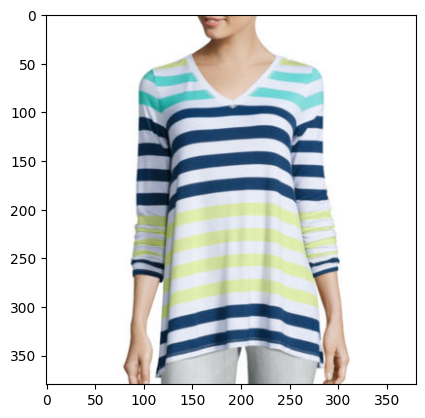

size after resizing (240, 240)


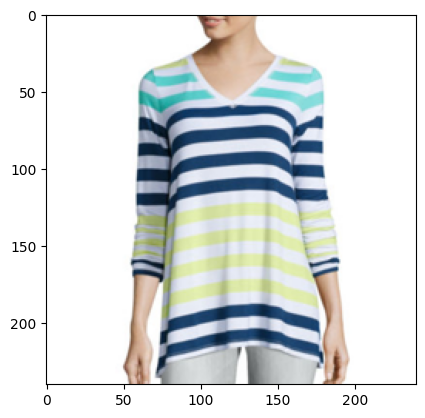

In [13]:
# In this section, we will load the product images using the URLs provided in the jcpenney_products.json file.
# After loading the images, we will resize them using PIL (Python Imaging Library) to optimize and compress the images for better performance and storage efficiency.
def load_image(url):
 """load image using url
 it will send get request to url and get content of image
 content is showed using BytesIO library
:param: url: url of the image
 """
 try:
  url_response = requests.get(url)
  image = Image.open(BytesIO(url_response.content))
  return image
 except Exception as ex:
  print("Error loading image",ex)
  return None

product_url = 'http://s7d9.scene7.com/is/image/JCPenney/DP1030201517035836M.tif?hei=380&a'
# To load and display the image, we will call a function that fetches the image from the provided URL.
# After loading the image, we can use the **matplotlib** (plt) library to show the image in our notebook or visualization tool. This allows us to visualize the image directly from the URL.
original_image = load_image(product_url)
print("size before resizing",original_image.size)
plt.imshow(original_image)
plt.show()
# In the resize function, we will provide specific width and height parameters to adjust the image size.
# This ensures the image is resized to the desired dimensions for better viewing or processing.
resized_image = original_image.resize((240,240))
print("size after resizing",resized_image.size)
plt.imshow(resized_image)
plt.show()

## **Data Validation**

* After exploring the data, it's crucial to validate whether the data is correct and reliable.  
* Ambiguous or incorrect data can lead to misleading or useless results, so performing **quality checks** is essential to ensure the integrity and accuracy of our data.  
* By validating the data, we can identify and correct any inconsistencies or errors before further analysis.

In [14]:
# The first step in data validation is to check for empty or null values in the DataFrame.
# Identifying missing or null values helps us understand data completeness and allows us to take necessary actions, such as filling, removing, or correcting these values.
display(products.isnull().sum())
display(users.isnull().sum())
display(reviews.isnull().sum())
display(jc_reviewers.isnull().sum())
display(jc_products.isnull().sum())

,0
SKU,67
Name,0
Description,543
Price,2166
Av_Score,0


,0
DOB,0
State,0


,0
Score,0
Review,0


,0
Username,0
DOB,0
State,0
Reviewed,0


,0
uniq_id,0
sku,0
name_title,0
description,1
list_price,4
sale_price,4
category,4
category_tree,4
average_product_rating,4
product_url,4


## **Data Cleaning**

* As observed, in the **products** DataFrame, there are multiple records with **NaN** (Not a Number) values, which can affect the accuracy of our statistics and analysis.  
* To ensure our data is reliable and can be used to generate correct insights, we need to perform the **data cleaning** process.  
* This process may involve filling missing values, removing incomplete records, or transforming the data to ensure it's ready for analysis.

In [15]:
# Before starting the cleaning process, we will first check for any records in the products DataFrame that contain null values.
# This will help us identify the extent of the missing data and determine the necessary steps for cleaning.
display(products[products.isnull().any(axis=1)].head())

,SKU,Name,Description,Price,Av_Score
Uniq_id,,,,,
4d9337e3c8f974d3c420cdc5c58b3fc3,pp5007090172,Alfred Dunner® Feels Like Spring 3/4-Sleeve Le...,Spring is in the air with our 3/4-sleeve leaf ...,NaN,1.0
44f8f8f108c6856acf9630dd1d78516d,pp5007080134,Alfred Dunner® Feels Like Spring 3/4-Sleeve Wa...,NaN,NaN,4.5
8d1d057f5f808c10ce243c222ab0ef6e,pp5007080134,Alfred Dunner® Feels Like Spring 3/4-Sleeve Wa...,NaN,NaN,2.5
f3e02c48f16b56e8c1f126c8fe762812,pp5007080134,Alfred Dunner® Feels Like Spring 3/4-Sleeve Wa...,NaN,NaN,1.0
8149f96381ad38bc848c1c12b7ad3228,pp5007080135,Alfred Dunner® Feels Like Spring Short-Sleeve ...,NaN,NaN,4.0


In [16]:
# The records above show that there are multiple rows with missing price, description, or SKU.
# It's clear that products without a price cannot be properly analyzed, products without an SKU can't be uniquely identified, and products without a description can't be described adequately.
# Therefore, these incomplete product records need to be removed first to maintain the integrity of our data.
products.dropna(subset=['Description', 'Price', 'SKU'], how='any', inplace=True)

In [17]:
# After performing the cleaning process, our records will no longer contain any empty or null values.
# This ensures that the data is complete and ready for further analysis, leading to more accurate results and insights.
display(products[products.isnull().any(axis=1)].head())

,SKU,Name,Description,Price,Av_Score
Uniq_id,,,,,


In [18]:
# Next, we will check for any negative prices in the dataset, as it is not possible for a product to have a negative price.
# Identifying and correcting these records is important to ensure data accuracy and consistency before proceeding with further analysis.
products[products['Price']<0].head()

,SKU,Name,Description,Price,Av_Score
Uniq_id,,,,,
af49185dcfd709b8a21f1b2fdf408cb9,pp5006510551,Xersion™ Go Swiftly Vest - Plus,Wear our vest for exercise or errands. It feat...,-65.27,1.600000
d98546105db42d9fb4b3d5f1ff0c1b3b,pp5006380890,Xersion™ Graphic Leggings - Tall,A splash of graphic excitement takes our Xersi...,-58.01,2.000000
d2cef6ebd8a99bf7aa7d1d7bc0583c06,pp5006380890,Xersion™ Graphic Leggings - Tall,A splash of graphic excitement takes our Xersi...,-58.01,5.000000
7ab9a41c73121f0c90b4641fe906f62e,pp5006380890,Xersion™ Graphic Leggings - Tall,A splash of graphic excitement takes our Xersi...,-58.01,4.000000
aae74d7df3f8247302ff4a8bed07fa96,pp5006350688,Xersion™ Graphic Tank Top - Girls 7-16 and Plus,"With bright color and easy comfort, this tank ...",-21.76,2.777778


In [19]:
# As we observe, there are multiple records with negative prices, which are clearly incorrect.
# To correct this, we will update these records and set their price to a positive value, ensuring that all product prices are valid and realistic.
products['Price'] = products['Price'].abs()
display(products[products['Price']<0].head())


,SKU,Name,Description,Price,Av_Score
Uniq_id,,,,,


In [20]:
# Upon further inspection, we can confirm that there are no negative price values in the dataset.
# The next step is to check for any duplicate records, as redundancy in the data can lead to skewed results.
# We will remove any duplicates to maintain the integrity of our dataset and ensure thorough quality checks.
display(products.duplicated().sum())
display(users.duplicated().sum())
display(reviews.duplicated().sum())
display(jc_reviewers.duplicated(subset=['Username', 'DOB', 'State']).sum())
display(jc_products.duplicated(subset=['list_price', 'sale_price', 'name_title','description']).sum())


np.int64(156)

np.int64(2586)

np.int64(3556)

np.int64(0)

np.int64(12112)

In [21]:
# We can see that there are several duplicate records throughout the dataset, which can affect the accuracy of our analysis.
# To ensure data quality and avoid redundancy, we will remove these duplicate entries from the dataset.
products.drop_duplicates(keep=False, inplace=True)
users.drop_duplicates(keep=False, inplace=True)
reviews.drop_duplicates(keep=False, inplace=True)
jc_products.drop_duplicates(subset=['list_price', 'sale_price', 'name_title','description'],keep=False, inplace=True)
jc_reviewers.drop_duplicates(subset=['Username', 'DOB', 'State'],keep=False, inplace=True)
display(jc_products.duplicated(subset=['list_price', 'sale_price', 'name_title','description']).sum())
display(products.duplicated().sum())
display(users.duplicated().sum())
display(reviews.duplicated().sum())


np.int64(0)

np.int64(0)

np.int64(0)

np.int64(0)

In [22]:
# In this step, we will check if any list_price or sale_price values are empty or null.
# Since both of these fields are crucial for analyzing product pricing, any records with missing values in these columns will be removed to maintain the data's integrity.
display(jc_products[jc_products['list_price'] == ''].head())
jc_products['list_price'].replace('', np.nan, inplace=True)
jc_products['sale_price'].replace('', np.nan, inplace=True)
# In this step, we will drop the NaN values from the jcpenney_products DataFrame.
# This will remove any rows with missing values, particularly in critical columns like list_price or sale_price, ensuring that the dataset is clean and complete for analysis.
jc_products.dropna(subset=['list_price', 'sale_price'], how='any', inplace=True)
display(jc_products[jc_products['list_price'] == ''].head())


,uniq_id,sku,name_title,description,list_price,sale_price,category,category_tree,average_product_rating,product_url,product_image_urls,brand,total_number_reviews,Reviews,Bought With
7,4d9337e3c8f974d3c420cdc5c58b3fc3,pp5007090172,Alfred Dunner® Feels Like Spring 3/4-Sleeve Le...,Spring is in the air with our 3/4-sleeve leaf ...,,70.1,skechers,jcpenney|women|skechers,1.000,http://www.jcpenney.com/alfred-dunner-feels-li...,http://s7d9.scene7.com/is/image/JCPenney/DP033...,Alfred Dunner,1,"[{'User': 'vivj4111', 'Review': 'The colors an...","[ac1c58ca9f2d61a98f4f88ec4594bb9a, 88632e0cb0c..."
72,4efca310d907bbac13d3562a8a4f6dfb,pp5005710039,Azul by Maxine of Hollywood Print Tankini Swim...,,,30.2032,view all brands,jcpenney|women|view all brands,3.625,http://www.jcpenney.com/azul-by-maxine-of-holl...,http://s7d9.scene7.com/is/image/JCPenney/DP062...,AZUL BY MAXINE OF HOLLYWOOD,8,"[{'User': 'xucx1233', 'Review': 'Love this swi...","[551ab3dd1fddad1b225879dab5d6ce43, d1fefd22e1b..."
102,ebb77604eeab5d9a83a0da94f4a73c6d,pp5005070981,Dickies® Womens Snap-Front Scrub Jacket,This warmup scrub jacket from Dickies offers a...,,33.84,scrubs & lab coats,jcpenney|men|scrubs & lab coats,2.750,http://www.jcpenney.com/dickies-womens-snap-fr...,http://s7d9.scene7.com/is/image/JCPenney/DP020...,Dickies,4,"[{'User': 'nexm4422', 'Review': 'This is a gre...","[c97b2e39d14f5bb09a73bd57d10e5e6d, 9aaaf42a269..."
103,adff887f8f9622ce81affc067a9535f6,pp5005030112,Dickies® Womens V-Neck Scrub Top–Plus,Multi-functional pockets and a loosely fitting...,,29.01,scrubs & lab coats,jcpenney|men|scrubs & lab coats,2.000,http://www.jcpenney.com/dickies-womens-v-neck-...,http://s7d9.scene7.com/is/image/JCPenney/DP011...,Dickies,1,"[{'User': 'vijp2233', 'Review': 'I was in need...","[f21a8bb8ff4a0896bd88234e4cdee0fb, d4ae1c136e2..."
104,1032abbe8c61bae452555e11482812b8,pp5004900610,Dickies® Womens V-Neck Scrub Top,Easily hold your essentials in this stretch-ea...,,38.68,scrubs & lab coats,jcpenney|men|scrubs & lab coats,3.000,http://www.jcpenney.com/dickies-womens-v-neck-...,http://s7d9.scene7.com/is/image/JCPenney/DP111...,Dickies,4,"[{'User': 'datm4432', 'Review': 'I will defini...","[2ef8b0cd40661e345b41789857314a61, 1e06e89fc7e..."


/tmp/ipykernel_4024/3314852417.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  jc_products['list_price'].replace('', np.nan, inplace=True)
/tmp/ipykernel_4024/3314852417.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

,uniq_id,sku,name_title,description,list_price,sale_price,category,category_tree,average_product_rating,product_url,product_image_urls,brand,total_number_reviews,Reviews,Bought With


## **Data Visualization**

* Now that our data is cleaned, the next step is to gain a deeper understanding by using **visualization**.  
* Python offers a wide range of functionalities to present statistical information in a **pictorial format**, which makes it easier to interpret and analyze data trends.  
* By visualizing the data, we can identify patterns, correlations, and insights that may not be immediately apparent in raw numbers.

In [23]:
# First, we will display the frequency of price in the products dataset.
# This visualization will help us understand the distribution of prices across all products, allowing us to identify price ranges and patterns within the dataset.
fig = px.scatter(products, x=products.index,
 y='Price',
 title='Scatter plot of prices (check outliers)',
 labels={'x': 'Index', 'Price': 'Price'},
 width=1000, height=600)
# Now, we will create a scatter plot to visualize the relationship between two numerical variables, such as list_price and sale_price.
# This plot will help us understand how these two variables are correlated, and whether there are any patterns or outliers in the data.
fig.show()

In [24]:
# As we can see in the scatter plot above, some prices are extremely high, which are skewing our visualization and acting as outliers.
# To address this, we will calculate the 95th percentile of the data and remove any prices that exceed this threshold.
# By doing so, we will filter out the extreme outliers and get a more accurate representation of the data distribution.
products_having_95_percentile = products['Price'].quantile(0.95)
products = products[products['Price'] < products_having_95_percentile ]


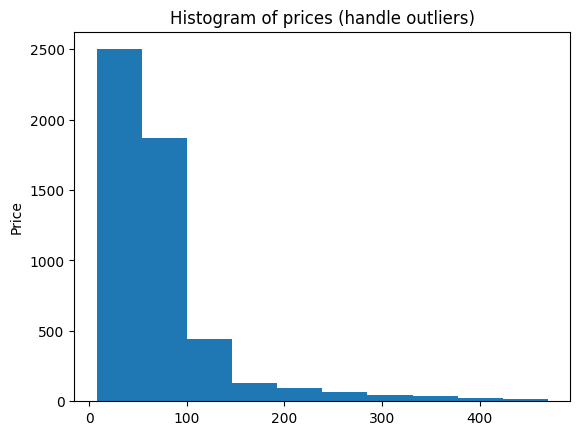

In [25]:
# Now, if we create a histogram plot of our products, it will display the data in its original form, giving us a clearer view of the distribution of prices or other numerical variables.
# This visualization will help us understand how the data is spread and highlight any trends or patterns that might not be immediately visible in other types of plots.
plt.hist(products['Price'])
# We need to label axis and title of our Histogram plot
plt.ylabel('Price')
plt.title('Histogram of prices (handle outliers)')
# Now its time to show the Histogram
plt.show()

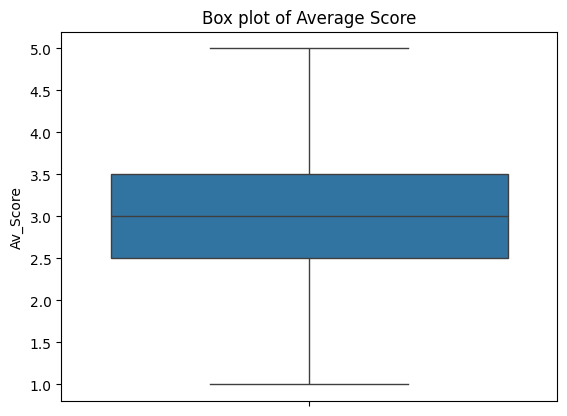

In [26]:
# We can also visualize a boxplot of the average score of all products, ranging from 1 to 5.
# This will give us an overview of how product ratings are distributed, highlighting the median score, any potential outliers, and the overall spread of ratings across the products.
sns.boxplot(products['Av_Score'])
# We need to label axis and title of our box plot against products Average Scoree
plt.ylabel('Av_Score')
plt.title('Box plot of Average Score')
plt.show()

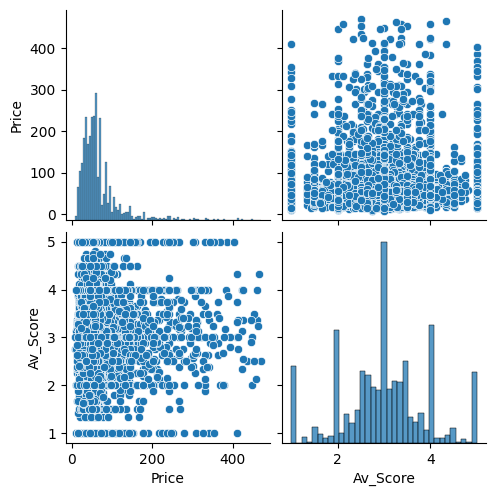

In [27]:
# Next, we will use a pairplot to visualize the correlation between the average score and price of the products.
# This will help us understand how customer satisfaction (through average ratings) is related to the pricing of products, providing insights that can guide decision-making regarding product pricing and customer satisfaction.
sns.pairplot(products[['Price', 'Av_Score']])
plt.show()

In [28]:
# Now, we will create an interactive scatter plot using Plotly to display the relationship between price and average score.
# This interactive plot will allow us to better explore the data, zoom in on specific points, and hover over the data points for additional details, offering a more dynamic and engaging way to analyze the correlation.
fig = px.scatter(products, x='Price', y='Av_Score', hover_data = ['Name'])
fig.update_layout(title='Rating of Price against Average score')
fig.show()


In [29]:
# Now, we will visualize the average review score per state.
# This will help us understand how customer satisfaction varies across different regions, providing insights into where products might be performing better or worse based on location.
merge_users_reviews = pd.merge(users, reviews, on='Username', how='inner')

In [30]:
# We will now perform a mean aggregation using the groupby function on the merged records.
# This will allow us to calculate the average values for each group, such as the average review score or price, based on specific attributes (e.g., state, product category, etc.).
# Grouping the data will help us uncover patterns and trends across different categories or segments.
avg_score_by_state = merge_users_reviews.groupby('State')['Score'].mean().reset_index()
# Ploting bar against average score by state
fig = px.bar(avg_score_by_state, x='State', y='Score',
 title='Average Review Score by State',
 labels={'Score': 'Average Score', 'State': 'State'},
 color='Score', color_continuous_scale=px.colors.sequential.Blues)
fig.update_layout(xaxis_title='State', yaxis_title='Average Score')
fig.show()


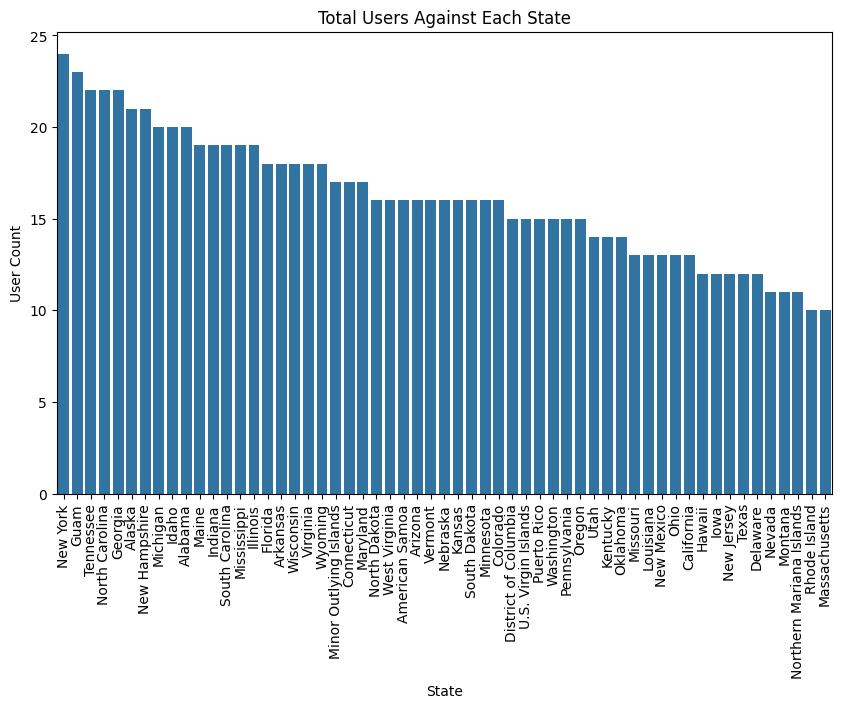

In [31]:
# Here, we will examine how many users exist in each state.
# From the analysis, we can observe that New York has the largest number of users in our dataset, indicating a strong user base in that region compared to others.
# This insight can help us focus on regions with more users or explore reasons behind such a concentration.
user_count_against_state = users['State'].value_counts().reset_index()
user_count_against_state.columns = ['State', 'count']
plt.figure(figsize=(10, 6))
sns.barplot(x='State', y='count', data=user_count_against_state)
plt.title('Total Users Against Each State')
plt.xlabel('State')
plt.ylabel('User Count')
plt.xticks(rotation=90)
plt.show()

##**Data Analysis**:  
  * In this section, we will perform in-depth **data analysis** to generate meaningful insights and statistics that can directly contribute to addressing business objectives and improving overall performance.  
  * The goal is to identify key trends, patterns, and factors that will help enhance decision-making, optimize processes, and ultimately drive business growth.

#**What are the basic sentimental analysis of reviews regarding users?**  
  * In this section, we will explore the sentiment behind user reviews, analyzing whether the feedback is generally **positive**, **negative**, or **neutral**.  
  * This analysis will provide valuable insights into customer satisfaction, highlight potential issues with products, and help identify areas for improvement in both product offerings and customer service.

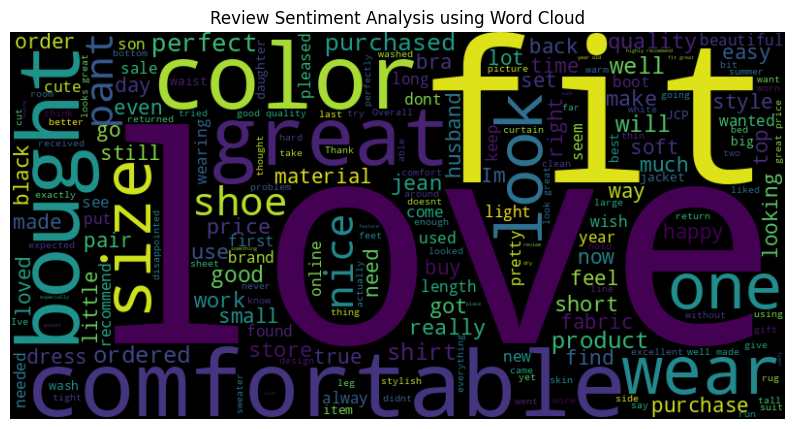

In [32]:
# A WordCloud visualizes the most frequent words in user reviews, highlighting key themes and customer sentiment.
# Larger words indicate higher frequency, offering insights into user feedback.
from wordcloud import WordCloud
text = ' '.join(review for review in reviews['Review'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text)
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Review Sentiment Analysis using Word Cloud')
plt.show()

#**Which Product Categories Have the Highest Average Rating?**  
  * Using the data from **jcpenny_products.csv**, we will analyze and identify which product categories receive the highest average ratings.  
  * This will allow us to pinpoint top-performing categories and better understand customer preferences.

In [33]:
# After converting jcpenny_products.json into a CSV for analysis, we will use it to identify the product category with the highest average rating.
# This will help us understand which categories are most appreciated by customers, providing valuable insights for product strategy.
product_average_rating_by_category = jc_products.groupby('category')['average_product_rating']
product_average_rating_by_category = product_average_rating_by_category.mean().sort_values(ascending=False)
display(product_average_rating_by_category)

,average_product_rating
category,
2-day deals,5.0
girl's school uniforms,5.0
timex,5.0
boys uniform shoes,5.0
cars,5.0
...,...
okie dokie,1.0
polos,1.0
furniture & decor,1.0


In [34]:
# Now we will show by plotting product category against its rating ussing plotly express
product_average_rating_df = product_average_rating_by_category.reset_index()  # Convert Series to DataFrame
fig = px.scatter(product_average_rating_df,
             x='category',
             y='average_product_rating',
             title='Average Ratings per Product Category',
             labels={'average_product_rating': 'Average Rating', 'category': 'Product Category'},
             width=1000,
             height=600)
fig.show()

##**Are There Any Products with a Major Difference Between List Price and Sale Price?**  
  * We will analyze the data to identify products where the difference between the list price and sale price is significant.  
  * This will help us understand pricing strategies and whether certain products are being heavily discounted.

In [35]:
# While analyzing the difference between list price and sale price, we identified that some sale prices contain special characters, like "26.59-47.14," and negative values in the list price.
# These entries need to be cleaned by removing records with special characters or invalid values before proceeding with further analysis.
special_character_rows_sale = jc_products[jc_products['sale_price'].str.contains(r'[^\d.]')]
special_character_rows_list = jc_products[jc_products['list_price'].str.contains(r'[^\d.]')]
jc_products = jc_products.drop(special_character_rows_sale.index)
jc_products = jc_products.drop(special_character_rows_list.index)
# Now we will check the price difference between list price and sale price
jc_products['price_difference'] = pd.to_numeric(jc_products['list_price']) - pd.to_numeric(jc_products['sale_price'])
price_with_differences = jc_products[jc_products['price_difference'] != 0]
display(price_with_differences[['name_title','price_difference']].head())


,name_title,price_difference
6,Alfred Dunner® Feels Like Spring 3/4 Sleeve Le...,26.11
28,Danny & Nicole® Sleeveless Lace Fit-and-Flare ...,38.69
29,Danny & Nicole® Sleeveless Lace Fit-and-Flare ...,26.60
30,Danny & Nicole® Sleeveless Lace Vertical Seam ...,26.60
31,Danny & Nicole® Sleeveless Mesh Shantung Polka...,44.73


##**What is the Distribution of Review Scores with Respect to Different Products?**  
  * We will analyze how review scores are distributed across different products.  
  * This will help us understand customer satisfaction for each product and identify trends in product performance based on reviews.

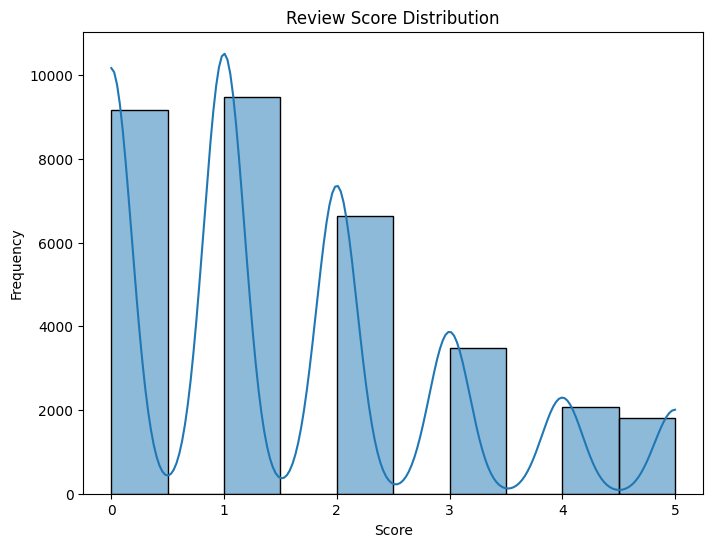

In [36]:
# We will plot the distribution of review scores using Kernel Density Estimation (KDE).
# This will allow us to visualize the frequency and smooth distribution of review scores, helping to identify patterns or trends in customer satisfaction across products.
plt.figure(figsize=(8,6))
sns.histplot(reviews['Score'], bins=10, kde=True)
plt.title('Review Score Distribution')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()


##**Do Certain Users Consistently Give Higher or Lower Scores in Their Reviews?**  
  * We will analyze whether specific users tend to give higher or lower review scores consistently.  
  * By aggregating review scores by username, we can observe if certain users show a pattern of giving higher or lower ratings across products, which could be useful for identifying biased or loyal reviewers.

In [37]:
# Get average score against each username
average_score_of_users = reviews.groupby('Username')['Score'].mean().reset_index().sort_values(by=['Score'])
display(average_score_of_users.head())

,Username,Score
1307,gwkk1224,0.0
4927,ztdo4243,0.0
2974,pqoe3411,0.0
3680,tgsp3112,0.0
3721,tmzz1142,0.0


In [38]:
# now we will display that using visualization of these records on the basis of username and score using plotly scatter
fig = px.scatter(average_score_of_users, x='Username',
 y='Score',
 title='Distribution of Review Scores Per User',
 labels={'Username': 'Usernames', 'Score': 'Review Scores'},
 width=1000, height=600)
fig.show()

#*What is the Age Distribution of Users Who Write Reviews?**  
  * We will examine the age distribution of users who have submitted reviews.  
  * By calculating the age of each user based on their date of birth, we can visualize how reviews are spread across different age groups, providing insight into the demographic profile of reviewers.

In [39]:
# We have to calculate age according to dob and get its distribution who write reviews
users['DOB'] = pd.to_datetime(users['DOB'], format='%d.%m.%Y') # Convert 'DOB' to datetime
users['Age'] = (datetime.now().date() - users['DOB'].dt.date).astype('string') # This line is updated to extract the date from the datetime object
fig = px.histogram(users, x='Age', nbins=40,
 title='Age Distribution of Users',
 labels = {'Age':'age', 'count':'count'},
 )
fig.show()

#**Is there any correlation between the number of reviews a product has and its average rating ?**

To explore the correlation between the number of reviews a product has and its average rating:

* **Merge Data**: Join `products` and `reviews` data using the product's `uniq_id` to combine product details with review counts.
* **Calculate Review Count**: Group data by `uniq_id` and count the number of reviews per product.
* **Plot the Correlation**: Visualize the relationship between the number of reviews and the average rating using a scatter plot.


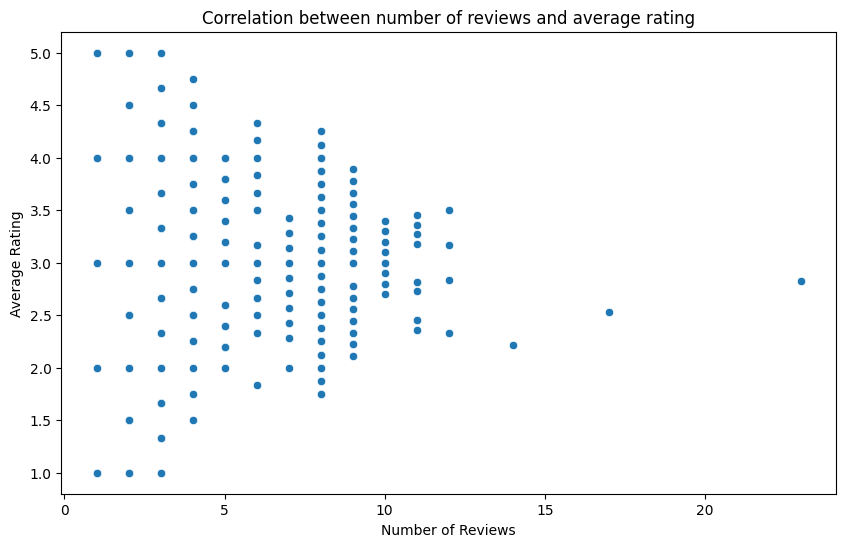

In [40]:
# Analyzing the correlation between total_number_reviews and average_product_rating to understand how the number of reviews impacts the product's average rating.
plt.figure(figsize=(10,6))
sns.scatterplot(x='total_number_reviews', y='average_product_rating', data=jc_products)
plt.title('Correlation between number of reviews and average rating')
plt.xlabel('Number of Reviews')
plt.ylabel('Average Rating')
plt.show()

###**Data Augmentation**  
  - A technique used to artificially expand a dataset by generating new data from the existing data.  
  - Helps improve model performance and generalization.  
  - Provides more robust insights, especially in cases with limited data.  
  - Commonly used in fields like image processing, natural language processing, and machine learning.

- # **Edge Detection**  
  - An image processing technique used to identify the boundaries or edges within an image.  
  - Highlights significant features, such as lines, contours, and object boundaries.  
  - Used in computer vision tasks for object recognition, image segmentation, and scene understanding.  
  - Common edge detection algorithms include Sobel, Canny, and Prewitt filters.

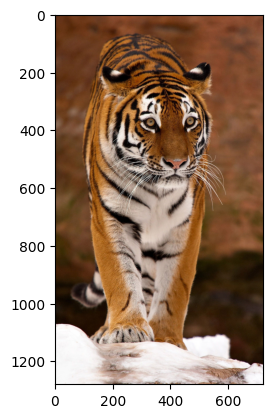

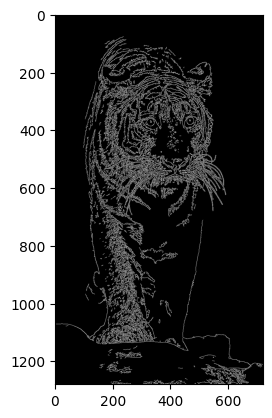

In [42]:
# Showing orignial image
original_image = Image.open('/content/drive/MyDrive/jcpenney-customer-insight-analysis/tiger.jpg')
plt.imshow(original_image)
plt.show()
# Reading the image for web
image = cv2.imread('/content/drive/MyDrive/jcpenney-customer-insight-analysis/tiger.jpg')
# Converting image to grayscale
gray_image = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
# Applying Canny Edges to image
canny = cv2.Canny(gray_image, 100, 200)
plt.imshow(canny, cmap= 'gray' )

# **Perform Image Augmentation**

**Flip image horizontally**

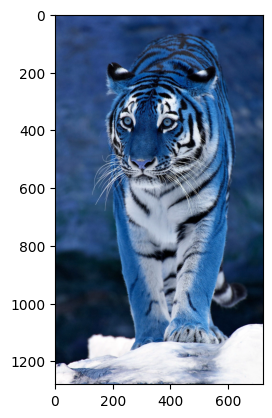

In [43]:
# flip image horizontal will change the colors of the image inversly
flipped_image = cv2.flip(image, 1)
plt.imshow(flipped_image)


#**Rotate the image by 45 Degrees**


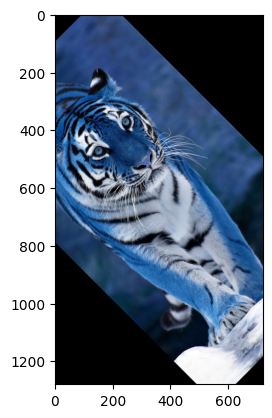

In [44]:
# Get rows and columns of image
rows, columns, _ = image.shape
# Rotation using open cv
mode_of_rotation = cv2.getRotationMatrix2D(( columns / 2, rows / 2) , 45, 1)
# Rotate the image
rotated_image = cv2.warpAffine(image, mode_of_rotation, (columns,rows ))
# Show the image
plt.imshow(rotated_image)